# 1. Setup and Imports

Import necessary libraries for data processing, SQL operations, and machine learning.

# Income Classification Project

## Project Overview
This notebook demonstrates a comprehensive machine learning pipeline for income classification using the Adult Census Income dataset. The project encompasses:
- **Data Cleaning**: Raw Python-based data preprocessing
- **Database Design**: SQL-based 3NF database structure
- **Exploratory Data Analysis**: Statistical analysis and visualization
- **Machine Learning**: Multiple experiments with various models and techniques
- **Model Optimization**: Feature engineering, dimensionality reduction, and class balancing

**Dataset**: Adult Census Income Evaluation Dataset  
**Target Variable**: Income (<=50K or >50K)  
**Objective**: Predict whether an individual's income exceeds $50K per year

In [190]:
import csv

In [191]:
file_path = '/content/income_evaluation.csv'

## 1.1 Data Source Configuration
Specify the path to the raw dataset file.

# 2. Data Cleaning with Raw Python

This section performs data cleaning using pure Python (csv module) without pandas:
- Remove duplicate rows
- Handle missing values (rows with '?' in workclass column)
- Strip whitespace from all fields
- Export cleaned data for further processing

In [192]:
# Step 1: Read the data and remove duplicates
rows = []
seen_rows = set()  # This will help us track duplicates

## 2.1 Read Data and Remove Duplicates
Read CSV file and track unique rows using a set to eliminate duplicates.

In [193]:
with open(file_path, mode='r') as file:
    reader = csv.reader(file)
    header = next(reader)  # Read the header row
    rows.append(header)  # Add the header to the rows list

    for row in reader:
        # Remove leading and trailing spaces from each element in the row
        row = [value.strip() for value in row]

        # Convert row to tuple for immutability (to add to set for uniqueness)
        row_tuple = tuple(row)
        if row_tuple not in seen_rows:
            seen_rows.add(row_tuple)
            rows.append(row)



## 2.2 Filter Invalid Records and Export
Remove rows with missing workclass values ('?') and save the cleaned dataset.

In [194]:
# Step 2: Handle missing or invalid values
# We will filter out rows where 'workclass' contains ' ?'
# Assuming the 'workclass' column is at index 1 (adjust as needed)

valid_rows = [header]  # Start with the header

for row in rows[1:]:  # Skip the header
    if row[1] != ' ?':  # Check if the 'workclass' column contains ' ?'
        valid_rows.append(row)

# Step 3: Write the cleaned data to a new file
output_file_path = 'cleaned_income_evaluation.csv'
with open(output_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(valid_rows)

print(f"Data cleaned and saved to {output_file_path}")

Data cleaned and saved to cleaned_income_evaluation.csv


# 3. SQL Database Design (3NF)

Create a normalized database structure in Third Normal Form (3NF) to:
- Eliminate data redundancy
- Ensure data integrity through foreign key relationships
- Organize data into logical entities

In [80]:
import sqlite3

# Connect to SQLite database (or create it)
conn = sqlite3.connect('income_evaluation.db')
cursor = conn.cursor()

# Create tables based on 3NF design with foreign key relationships
cursor.execute('''
CREATE TABLE IF NOT EXISTS Personal_Details (
    ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Age INTEGER,
    Race TEXT,
    Sex TEXT,
    Relationship TEXT
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Employment_Details (
    ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Personal_ID INTEGER,  -- Foreign key referencing Personal_Details
    Workclass TEXT,
    Occupation TEXT,
    Hours_per_Week INTEGER,
    Income TEXT,
    FOREIGN KEY (Personal_ID) REFERENCES Personal_Details(ID)
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Education_Details (
    ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Personal_ID INTEGER,  -- Foreign key referencing Personal_Details
    Education TEXT,
    Education_Num INTEGER,
    FOREIGN KEY (Personal_ID) REFERENCES Personal_Details(ID)
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Financial_Details (
    ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Personal_ID INTEGER,  -- Foreign key referencing Personal_Details
    Capital_Gain INTEGER,
    Capital_Loss INTEGER,
    Fnlwgt INTEGER,
    FOREIGN KEY (Personal_ID) REFERENCES Personal_Details(ID)
);
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Location_Details (
    ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Personal_ID INTEGER,  -- Foreign key referencing Personal_Details
    Native_Country TEXT,
    FOREIGN KEY (Personal_ID) REFERENCES Personal_Details(ID)
);
''')

# Commit the changes and close the connection
conn.commit()
conn.close()

print("3NF structure created successfully!")


3NF structure created successfully!


## 3.1 Create 3NF Database Schema

Database Tables:
- **Personal_Details**: Age, Race, Sex, Relationship
- **Employment_Details**: Workclass, Occupation, Hours per Week, Income
- **Education_Details**: Education, Education Number
- **Financial_Details**: Capital Gain, Capital Loss, Final Weight
- **Location_Details**: Native Country

All tables reference Personal_Details via foreign key relationships.

In [81]:
import csv

file_path = 'cleaned_income_evaluation.csv'
with open(file_path, mode='r') as file:
    reader = csv.DictReader(file)  # Using DictReader to read each row as a dictionary
    first_row = next(reader)  # Read the first row to inspect column names

    # Print the column names
    print("Columns in CSV:", first_row.keys())  # Display the keys (column names)

    # Optionally, print the first row's data to verify values
    print("First row data:", first_row)


Columns in CSV: dict_keys(['age', ' workclass', ' fnlwgt', ' education', ' education-num', ' marital-status', ' occupation', ' relationship', ' race', ' sex', ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country', ' income'])
First row data: {'age': '39', ' workclass': 'State-gov', ' fnlwgt': '77516', ' education': 'Bachelors', ' education-num': '13', ' marital-status': 'Never-married', ' occupation': 'Adm-clerical', ' relationship': 'Not-in-family', ' race': 'White', ' sex': 'Male', ' capital-gain': '2174', ' capital-loss': '0', ' hours-per-week': '40', ' native-country': 'United-States', ' income': '<=50K'}


## 3.2 Inspect CSV Columns
Verify column names in the cleaned CSV file before database insertion.

In [82]:
# Open the cleaned CSV file and read the data
file_path = 'cleaned_income_evaluation.csv'
with open(file_path, mode='r') as file:
    reader = csv.DictReader(file)  # Using DictReader to read each row as a dictionary

    # Remove leading/trailing spaces from column names
    fieldnames = [field.strip() for field in reader.fieldnames]
    reader.fieldnames = fieldnames  # Update the reader's fieldnames

    data_no_duplicates = [row for row in reader]  # Assuming data_no_duplicates is ready

# Insert data into tables
for row in data_no_duplicates:
    # Insert into Personal_Details table
    cursor.execute('''
    INSERT INTO Personal_Details (Age, Race, Sex, Relationship)
    VALUES (?, ?, ?, ?)
    ''', (row['age'], row['race'], row['sex'], row['relationship']))

    # Get the ID of the last inserted row (Personal_ID)
    personal_id = cursor.lastrowid

    # Insert into Employment_Details table
    cursor.execute('''
    INSERT INTO Employment_Details (Personal_ID, Workclass, Occupation, Hours_per_Week, Income)
    VALUES (?, ?, ?, ?, ?)
    ''', (personal_id, row['workclass'], row['occupation'], row['hours-per-week'], row['income']))

    # Insert into Education_Details table
    cursor.execute('''
    INSERT INTO Education_Details (Personal_ID, Education, Education_Num)
    VALUES (?, ?, ?)
    ''', (personal_id, row['education'], row['education-num']))

    # Insert into Financial_Details table
    cursor.execute('''
    INSERT INTO Financial_Details (Personal_ID, Capital_Gain, Capital_Loss, Fnlwgt)
    VALUES (?, ?, ?, ?)
    ''', (personal_id, row['capital-gain'], row['capital-loss'], row['fnlwgt']))

    # Insert into Location_Details table
    cursor.execute('''
    INSERT INTO Location_Details (Personal_ID, Native_Country)
    VALUES (?, ?)
    ''', (personal_id, row['native-country']))

# Commit the changes and close the connection
conn.commit()
conn.close()

print("Data inserted into 3NF tables successfully!")

ProgrammingError: Cannot operate on a closed database.

## 3.3 Populate Database Tables
Insert cleaned data into the normalized database structure, maintaining referential integrity through Personal_ID foreign keys.

# 4. Data Retrieval with SQL JOIN

Reconstruct the complete dataset by joining all normalized tables using SQL JOIN operations.

In [230]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect('income_evaluation.db')

# SQL JOIN statement to fetch data from multiple tables
sql_query = '''
SELECT
    pd.Age,
    pd.Race,
    pd.Sex,
    pd.Relationship,
    ed.Workclass,
    ed.Occupation,
    ed.Hours_per_Week,
    ed.Income,
    edu.Education,
    edu.Education_Num,
    fd.Capital_Gain,
    fd.Capital_Loss,
    fd.Fnlwgt,
    ld.Native_Country
FROM
    Personal_Details pd
JOIN
    Employment_Details ed ON pd.ID = ed.Personal_ID
JOIN
    Education_Details edu ON pd.ID = edu.Personal_ID
JOIN
    Financial_Details fd ON pd.ID = fd.Personal_ID
JOIN
    Location_Details ld ON pd.ID = ld.Personal_ID;
'''

# Execute the query and load the data into a Pandas DataFrame
df = pd.read_sql_query(sql_query, conn)

# Close the connection
conn.close()

# Display the first few rows of the DataFrame
print(df.head())


   Age   Race     Sex   Relationship         Workclass         Occupation  \
0   39  White    Male  Not-in-family         State-gov       Adm-clerical   
1   50  White    Male        Husband  Self-emp-not-inc    Exec-managerial   
2   38  White    Male  Not-in-family           Private  Handlers-cleaners   
3   53  Black    Male        Husband           Private  Handlers-cleaners   
4   28  Black  Female           Wife           Private     Prof-specialty   

   Hours_per_Week Income  Education  Education_Num  Capital_Gain  \
0              40  <=50K  Bachelors             13          2174   
1              13  <=50K  Bachelors             13             0   
2              40  <=50K    HS-grad              9             0   
3              40  <=50K       11th              7             0   
4              40  <=50K  Bachelors             13             0   

   Capital_Loss  Fnlwgt Native_Country  
0             0   77516  United-States  
1             0   83311  United-States  
2    

## 4.1 Execute JOIN Query
Perform multi-table JOIN to combine all related information and load into a Pandas DataFrame for analysis.

# 5. Exploratory Data Analysis (EDA)

Analyze the dataset using Pandas to understand distributions, correlations, and data quality.

Income Distribution:
 Income
<=50K    24698
>50K      7839
Name: count, dtype: int64


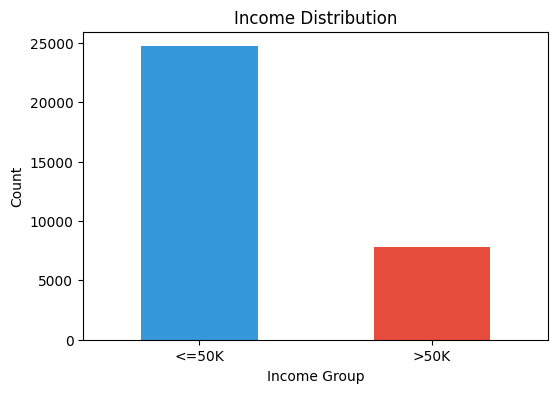

In [196]:
import pandas as pd

# Assuming 'df' is the Pandas DataFrame containing the joined data
# Check the distribution of the target variable 'Income'
income_distribution = df['Income'].value_counts()

# Display the distribution
print("Income Distribution:\n", income_distribution)

# Visualize the distribution of the 'Income' column
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
income_distribution.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Income Distribution")
plt.xlabel("Income Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 5.1 Target Variable Distribution
Analyze the distribution of the target variable (Income) to check for class imbalance.

In [197]:
from sklearn.model_selection import train_test_split

# Features (X) and target variable (y)
X = df.drop(columns='Income')  # Features (all columns except 'Income')
y = df['Income']  # Target variable

# Perform stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Check the distribution in the training and test sets
print("Training set Income distribution:\n", y_train.value_counts())
print("Test set Income distribution:\n", y_test.value_counts())


Training set Income distribution:
 Income
<=50K    19758
>50K      6271
Name: count, dtype: int64
Test set Income distribution:
 Income
<=50K    4940
>50K     1568
Name: count, dtype: int64


## 5.2 Train-Test Split with Stratification
Split data into training and testing sets while maintaining class distribution using stratified sampling.

In [198]:
#pip install ydata-profiling

In [29]:
from ydata_profiling import ProfileReport

# Generate the profile report for the DataFrame
profile = ProfileReport(df, title="Income Evaluation Dataset EDA", explorative=True)

# Save the report as an HTML file
profile.to_file("income_evaluation_eda_report.html")

# Optionally, display the report in Jupyter Notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 5.3 Automated EDA Report
Generate a comprehensive EDA report using ydata-profiling (pandas-profiling) for detailed statistical analysis.

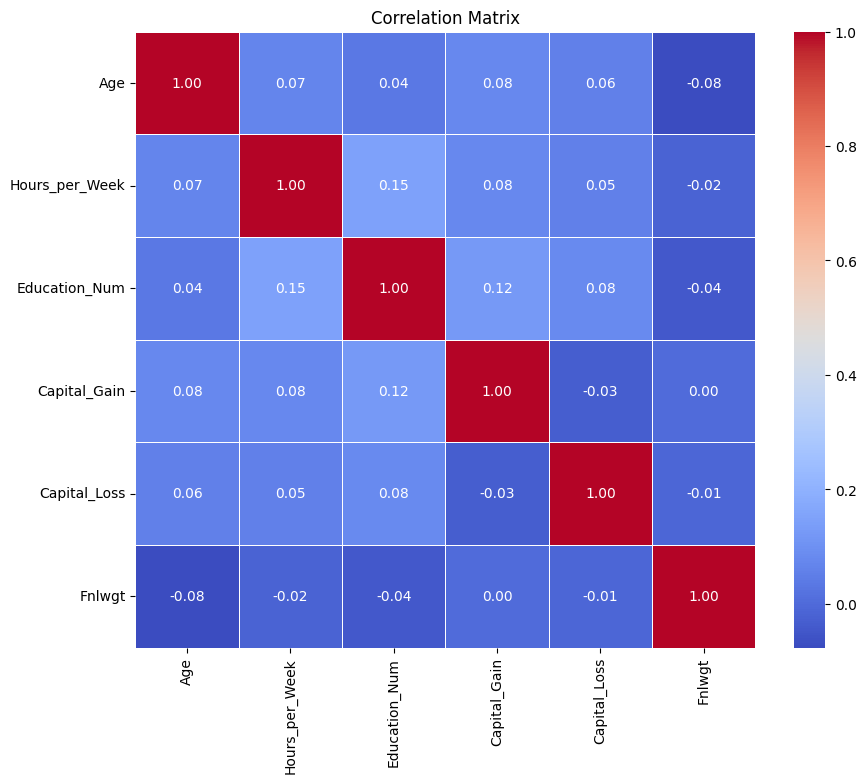

In [199]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix for numeric columns
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


## 5.4 Correlation Matrix Heatmap
Visualize correlations between numeric features to identify multicollinearity and feature relationships.

In [200]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Strip leading and trailing spaces from all column names
# df.columns = df.columns.str.strip()

# # Step 1: Check for missing values
# missing_values = df.isna().sum()
# print("Missing values per column:\n", missing_values)

# # Handle missing values
# # For example, we can impute missing categorical columns with the mode and numerical with median
# df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
# df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)

# # Step 2: Identify duplicate rows
# duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {duplicates}")

# # Remove duplicate rows
# df.drop_duplicates(inplace=True)

# # Step 3: Feature distributions - Plot histograms for numeric features
# numeric_features = df.select_dtypes(include=['number']).columns

# # Plot distributions for each numeric feature
# for feature in numeric_features:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(df[feature], kde=True, bins=30)
#     plt.title(f'Distribution of {feature}')
#     plt.show()

# # Step 4: Check for capped values or unusual values
# # Look for extremely high or low values that may need capping
# for feature in numeric_features:
#     print(f"Max and Min values for {feature}: {df[feature].max()}, {df[feature].min()}")

#     # Capping logic for extreme values
#     if feature == 'capital-gain' and df[feature].max() > 1e6:
#         df[feature] = np.where(df[feature] > 1e6, 1e6, df[feature])
#     elif feature == 'fnlwgt' and df[feature].max() > 1e7:
#         df[feature] = np.where(df[feature] > 1e7, 1e7, df[feature])

# # Step 5: Apply log transformation to skewed features (like capital-gain, fnlwgt)
# df['capital-gain'] = np.log1p(df['capital-gain'])
# df['fnlwgt'] = np.log1p(df['fnlwgt'])

# # Step 6: List cleanup tasks
# cleanup_tasks = []

# # Check for missing values
# for column in missing_values.index:
#     if missing_values[column] > 0:
#         cleanup_tasks.append(f"Handle missing values in {column}")

# # Check for duplicates
# if duplicates > 0:
#     cleanup_tasks.append("Remove duplicate rows")

# # Check for capped values
# for feature in numeric_features:
#     if df[feature].max() > 1e6:
#         cleanup_tasks.append(f"Check for capping needed in {feature}")

# # Final list of cleanup tasks
# print("\nCleanup tasks:")
# for task in cleanup_tasks:
#     print(f"- {task}")

# # Optionally, you can save the cleaned data for further use
# df.to_csv('income_evaluation_cleaned.csv', index=False)


In [201]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## 5.5 Check for Duplicate Rows
Verify data quality by checking for any remaining duplicate records.

In [202]:
#%pip install -q dagshub mlflow

In [203]:
import dagshub
dagshub.init(repo_owner='Profit188', repo_name='Clasification_Income', mlflow=True)

Initialized MLflow to track repo "Profit188/Clasification_Income"

Repository Profit188/Clasification_Income initialized!

# 6. MLflow Experiment Tracking Setup

Initialize DagsHub and MLflow for experiment tracking and model versioning.

In [204]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/Profit188/Clasification_Income.mlflow")

## 6.1 Configure MLflow Tracking URI
Set the remote tracking server for logging experiments.

In [205]:
#ex1

In [231]:
df

,Age,Race,Sex,Relationship,Workclass,Occupation,Hours_per_Week,Income,Education,Education_Num,Capital_Gain,Capital_Loss,Fnlwgt,Native_Country
0,39,White,Male,Not-in-family,State-gov,Adm-clerical,40,<=50K,Bachelors,13,2174,0,77516,United-States
1,50,White,Male,Husband,Self-emp-not-inc,Exec-managerial,13,<=50K,Bachelors,13,0,0,83311,United-States
2,38,White,Male,Not-in-family,Private,Handlers-cleaners,40,<=50K,HS-grad,9,0,0,215646,United-States
3,53,Black,Male,Husband,Private,Handlers-cleaners,40,<=50K,11th,7,0,0,234721,United-States
4,28,Black,Female,Wife,Private,Prof-specialty,40,<=50K,Bachelors,13,0,0,338409,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,White,Female,Wife,Private,Tech-support,38,<=50K,Assoc-acdm,12,0,0,257302,United-States
32533,40,White,Male,Husband,Private,Machine-op-inspct,40,>50K,HS-grad,9,0,0,154374,United-States
32534,58,White,Female,Unmarried,Private,Adm-clerical,40,<=50K,HS-grad,9,0,0,151910,United-States
32535,22,White,Male,Own-child,Private,Adm-clerical,20,<=50K,HS-grad,9,0,0,201490,United-States


In [232]:
df.drop(columns=['Race'],axis=True)

,Age,Sex,Relationship,Workclass,Occupation,Hours_per_Week,Income,Education,Education_Num,Capital_Gain,Capital_Loss,Fnlwgt,Native_Country
0,39,Male,Not-in-family,State-gov,Adm-clerical,40,<=50K,Bachelors,13,2174,0,77516,United-States
1,50,Male,Husband,Self-emp-not-inc,Exec-managerial,13,<=50K,Bachelors,13,0,0,83311,United-States
2,38,Male,Not-in-family,Private,Handlers-cleaners,40,<=50K,HS-grad,9,0,0,215646,United-States
3,53,Male,Husband,Private,Handlers-cleaners,40,<=50K,11th,7,0,0,234721,United-States
4,28,Female,Wife,Private,Prof-specialty,40,<=50K,Bachelors,13,0,0,338409,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,Female,Wife,Private,Tech-support,38,<=50K,Assoc-acdm,12,0,0,257302,United-States
32533,40,Male,Husband,Private,Machine-op-inspct,40,>50K,HS-grad,9,0,0,154374,United-States
32534,58,Female,Unmarried,Private,Adm-clerical,40,<=50K,HS-grad,9,0,0,151910,United-States
32535,22,Male,Own-child,Private,Adm-clerical,20,<=50K,HS-grad,9,0,0,201490,United-States


# 7. Feature Engineering - Data Encoding

Transform categorical variables into numerical format for machine learning algorithms.

In [233]:
categorical_cols = ["Sex", "Relationship", "Workclass", "Occupation", "Native_Country", "Education"]

# Apply Label Encoding to ordinal columns (e.g., Education)
label_encoder = LabelEncoder()
df["Education"] = label_encoder.fit_transform(df["Education"])

# Apply One-Hot Encoding to nominal columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Now df_encoded has all the categorical variables converted to numerical ones

# Display the first few rows to verify the encoding
print(df_encoded.head())

   Age   Race  Hours_per_Week Income  Education_Num  Capital_Gain  \
0   39  White              40  <=50K             13          2174   
1   50  White              13  <=50K             13             0   
2   38  White              40  <=50K              9             0   
3   53  Black              40  <=50K              7             0   
4   28  Black              40  <=50K             13             0   

   Capital_Loss  Fnlwgt  Sex_Male  Relationship_Not-in-family  ...  \
0             0   77516      True                        True  ...   
1             0   83311      True                       False  ...   
2             0  215646      True                        True  ...   
3             0  234721      True                       False  ...   
4             0  338409     False                       False  ...   

   Education_6  Education_7  Education_8  Education_9  Education_10  \
0        False        False        False         True         False   
1        False        

## 7.1 Encode Categorical Variables
Apply Label Encoding for ordinal features (Education) and One-Hot Encoding for nominal features.

In [234]:
df_encoded = df_encoded.drop('Race', axis=1)

## 7.2 Remove Redundant Features
Drop the 'Race' column as it may introduce bias and is not needed for prediction.

In [235]:
df_encoded['Income'] = df_encoded['Income'].map({'<=50K': 0, '>50K': 1})

## 7.3 Encode Target Variable
Convert Income labels to binary format: <=50K → 0, >50K → 1

In [236]:
df_encoded = df_encoded.astype(int)

## 7.4 Convert to Integer Type
Ensure all features are in integer format for model compatibility.

In [237]:
df_encoded

,Age,Hours_per_Week,Income,Education_Num,Capital_Gain,Capital_Loss,Fnlwgt,Sex_Male,Relationship_Not-in-family,Relationship_Other-relative,...,Education_6,Education_7,Education_8,Education_9,Education_10,Education_11,Education_12,Education_13,Education_14,Education_15
0,39,40,0,13,2174,0,77516,1,1,0,...,0,0,0,1,0,0,0,0,0,0
1,50,13,0,13,0,0,83311,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,38,40,0,9,0,0,215646,1,1,0,...,0,0,0,0,0,1,0,0,0,0
3,53,40,0,7,0,0,234721,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,28,40,0,13,0,0,338409,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27,38,0,12,0,0,257302,0,0,0,...,0,1,0,0,0,0,0,0,0,0
32533,40,40,1,9,0,0,154374,1,0,0,...,0,0,0,0,0,1,0,0,0,0
32534,58,40,0,9,0,0,151910,0,0,0,...,0,0,0,0,0,1,0,0,0,0
32535,22,20,0,9,0,0,201490,1,0,0,...,0,0,0,0,0,1,0,0,0,0


# 8. Machine Learning Experiments

## Experiment 1: Baseline Logistic Regression with Hyperparameter Tuning

**Objective**: Establish baseline performance using Logistic Regression  
**Technique**: GridSearchCV for hyperparameter optimization  
**Metrics**: F1-Score, Confusion Matrix  
**Parameters Tuned**: Regularization (C), Penalty (L1/L2)

In [238]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import f1_score, confusion_matrix
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into features and target
X = df_encoded.drop(columns=['Income'])
y = df_encoded['Income']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# Define the preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define the pipeline with Logistic Regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validation setup
cv = 10  # Number of folds for cross-validation



## 8.1 Setup Baseline Pipeline
Create preprocessing pipeline with scaling and one-hot encoding for categorical features.

In [239]:
mlflow.set_experiment("Experiment 1 - Income_Classification_Experiment")


<Experiment: artifact_location='mlflow-artifacts:/263ae57d632843998ead634b1c83dd36', creation_time=1734498077130, experiment_id='10', last_update_time=1734498077130, lifecycle_stage='active', name='Experiment 1 - Income_Classification_Experiment', tags={}>

In [240]:
# Start MLflow run
with mlflow.start_run(run_name="Experiment 1"):
    # Train the model and perform cross-validation
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring='f1', return_train_score=True
    )

    # Get the mean and standard deviation of F1-scores
    mean_f1 = np.mean(scores['test_score'])
    std_f1 = np.std(scores['test_score'])

    # Log metrics with MLflow
    mlflow.log_metric('mean_f1_score', mean_f1)
    mlflow.log_metric('std_f1_score', std_f1)

    # Hyperparameter tuning using GridSearchCV
    param_grid = {
        'classifier__C': [0.1, 1, 10],  # Regularization parameter for Logistic Regression
        'classifier__penalty': ['l2', 'l1'],  # Regularization penalties
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Log the best hyperparameters
    best_params = grid_search.best_params_
    mlflow.log_params(best_params)

    # Evaluate on the test set
    y_pred = grid_search.predict(X_test)
    f1_test = f1_score(y_test, y_pred, average='binary')
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Log the results on the test set
    mlflow.log_metric('f1_test', f1_test)
    mlflow.log_metric('tn', tn)
    mlflow.log_metric('fp', fp)
    mlflow.log_metric('fn', fn)
    mlflow.log_metric('tp', tp)

    # Log the trained model
    mlflow.sklearn.log_model(grid_search.best_estimator_, "logistic_regression_model")

print("Experiment complete and results logged to MLflow!")

2024/12/18 05:12:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Experiment 1 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/10/runs/3af84efd7cc54c0793027c7acb0933ba
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/10
Experiment complete and results logged to MLflow!


## 8.2 Train and Log Experiment 1
Perform 10-fold cross-validation and log results to MLflow.

In [241]:
print(f"Number of NaN values in 'income': {df_encoded['Income'].isna().sum()}")


Number of NaN values in 'income': 0


In [242]:
df_encoded.columns

Index(['Age', 'Hours_per_Week', 'Income', 'Education_Num', 'Capital_Gain',
       'Capital_Loss', 'Fnlwgt', 'Sex_Male', 'Relationship_Not-in-family',
       'Relationship_Other-relative', 'Relationship_Own-child',
       'Relationship_Unmarried', 'Relationship_Wife', 'Workclass_Federal-gov',
       'Workclass_Local-gov', 'Workclass_Never-worked', 'Workclass_Private',
       'Workclass_Self-emp-inc', 'Workclass_Self-emp-not-inc',
       'Workclass_State-gov', 'Workclass_Without-pay',
       'Occupation_Adm-clerical', 'Occupation_Armed-Forces',
       'Occupation_Craft-repair', 'Occupation_Exec-managerial',
       'Occupation_Farming-fishing', 'Occupation_Handlers-cleaners',
       'Occupation_Machine-op-inspct', 'Occupation_Other-service',
       'Occupation_Priv-house-serv', 'Occupation_Prof-specialty',
       'Occupation_Protective-serv', 'Occupation_Sales',
       'Occupation_Tech-support', 'Occupation_Transport-moving',
       'Native_Country_Cambodia', 'Native_Country_Canada',
    

In [ ]:
# Experiment 2: Model Comparison

**Objective**: Compare multiple classification algorithms  
**Models**: Logistic Regression, Ridge Classifier, Random Forest, XGBoost  
**Validation**: 3-fold Stratified Cross-Validation  
**Metrics**: F1-Score (Macro), Confusion Matrix

2024/12/18 05:18:07 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #2' does not exist. Creating a new experiment.
2024/12/18 05:18:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: LogisticRegression
Mean CV F1-Score: 0.6309, STD: 0.0022
🏃 View run LogisticRegression at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11/runs/027bac70dc3a4b31a6e08501267f306c
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11


2024/12/18 05:18:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RidgeClassifier
Mean CV F1-Score: 0.7490, STD: 0.0030
🏃 View run RidgeClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11/runs/b15ae13f9ece4dae9b08c81252f3b05e
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11


2024/12/18 05:18:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.7802, STD: 0.0072
🏃 View run RandomForestClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11/runs/567d866729cf4c15a3d39d5856c69e95
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11


2024/12/18 05:19:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: XGBClassifier
Mean CV F1-Score: 0.8087, STD: 0.0037
🏃 View run XGBClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11/runs/32879804465e45bdae72af6ee4a793b3
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/11


In [245]:
### ex3

# Experiment 3: Feature Engineering with Polynomial Features

**Objective**: Improve model performance through feature engineering  
**New Features**:
- Age to Hours Ratio: `Age / Hours_per_Week`
- Age Squared: `Age²`
- Hours per Week Squared: `Hours_per_Week²`
- Age-Hours Interaction: `Age × Hours_per_Week`

**Purpose**: Capture non-linear relationships and interactions between features

In [247]:
mlflow.set_experiment("Experiment #3")

2024/12/18 05:19:51 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #3' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1849dc4eba284290ba21e28f764db764', creation_time=1734499191694, experiment_id='12', last_update_time=1734499191694, lifecycle_stage='active', name='Experiment #3', tags={}>

In [248]:
df_encoded['Age_to_hours_ratio'] = df_encoded['Age'] / df_encoded['Hours_per_Week']
df_encoded['Age_squared'] = df_encoded['Age'] ** 2
df_encoded['Hours_per_week_squared'] = df_encoded['Hours_per_Week'] ** 2

# You can create interaction features like the product of age and hours-per-week
df_encoded['Age_hours_interaction'] = df_encoded['Age'] * df_encoded['Hours_per_Week']

# Separate features and target
X = df_encoded.drop("Income", axis=1)  # 'income' is the target column
y = df_encoded["Income"]

# Encode Target Variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Define models for the pipeline
models = {
    "LogisticRegression": LogisticRegression(solver="liblinear"),
    "RidgeClassifier": RidgeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBClassifier": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}

# Cross-validation & Metrics Logging
def log_metrics(model, X, y):
    y_pred = model.predict(X)
    f1 = f1_score(y, y_pred)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    return {"F1-Score": f1, "TP": tp, "TN": tn, "FP": fp, "FN": fn}

## 8.3 Create Engineered Features
Add polynomial and interaction features to capture non-linear patterns.

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Loop through models and log metrics to MLFlow
for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("Model", model_name)

        # Create pipeline for each model
        pipeline = Pipeline([
            ("classifier", model)
        ])

        # Cross-Validation
        kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring="f1_macro")
        mean_score = scores.mean()
        std_score = scores.std()

        # Train the model on the full training data
        pipeline.fit(X_train, y_train)
        metrics = log_metrics(pipeline, X_test, y_test)

        # Log Metrics to MLFlow
        mlflow.log_metric("Mean_CV_F1", mean_score)
        mlflow.log_metric("STD_CV_F1", std_score)
        for key, value in metrics.items():
            mlflow.log_metric(key, value)

        # Log the model
        mlflow.sklearn.log_model(pipeline, f"{model_name}_pipeline")

        print(f"Model: {model_name}")
        print(f"Mean CV F1-Score: {mean_score:.4f}, STD: {std_score:.4f}")

2024/12/18 05:21:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: LogisticRegression
Mean CV F1-Score: 0.6577, STD: 0.0105
🏃 View run LogisticRegression at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12/runs/da8d7326a37243a88f5ae01a99a36cb8
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12


2024/12/18 05:22:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RidgeClassifier
Mean CV F1-Score: 0.7538, STD: 0.0031
🏃 View run RidgeClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12/runs/c33c30a97ddb45a3868b635f97cb72e6
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12


2024/12/18 05:22:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.7767, STD: 0.0088
🏃 View run RandomForestClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12/runs/56bdbb043c274bc498677c79ba145563
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12


2024/12/18 05:22:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: XGBClassifier
Mean CV F1-Score: 0.8072, STD: 0.0026
🏃 View run XGBClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12/runs/111f2c64e80440baa981042ae0a06ce7
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/12


# Experiment 4: Feature Selection Techniques

**Objective**: Reduce dimensionality and improve model performance by selecting relevant features  
**Methods**:
1. **Correlation Threshold**: Remove highly correlated features (threshold = 0.9)
2. **Feature Importance**: Select features based on Random Forest importance scores
3. **Variance Threshold**: Remove low-variance features (threshold = 0.01)

**Models Tested**: Random Forest, XGBoost

In [251]:
mlflow.set_experiment("Experiment #4")

2024/12/18 05:23:10 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #4' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/4264271b807248988f86c26f4b896100', creation_time=1734499390083, experiment_id='13', last_update_time=1734499390083, lifecycle_stage='active', name='Experiment #4', tags={}>

In [252]:
from sklearn.feature_selection import VarianceThreshold
X = df_encoded.drop("Income", axis=1)  # 'income' is the target column
y = df_encoded["Income"]
def correlation_threshold(X, threshold=0.9):
    corr_matrix = X.corr()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > threshold)]
    return X.drop(columns=to_drop)

# Feature Selection Method 2: Feature Importance using RandomForestClassifier
def feature_importance(X, y):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
    important_features = feature_importance[feature_importance > 0.01]  # Set a threshold for importance
    return X[important_features.index]

# Feature Selection Method 3: Variance Threshold
def variance_threshold(X, threshold=0.01):
    selector = VarianceThreshold(threshold=threshold)
    return X.loc[:, selector.fit(X).get_support()]

## 8.4 Define Feature Selection Functions
Implement three different feature selection strategies.

In [253]:
df_encoded.columns

Index(['Age', 'Hours_per_Week', 'Income', 'Education_Num', 'Capital_Gain',
       'Capital_Loss', 'Fnlwgt', 'Sex_Male', 'Relationship_Not-in-family',
       'Relationship_Other-relative', 'Relationship_Own-child',
       'Relationship_Unmarried', 'Relationship_Wife', 'Workclass_Federal-gov',
       'Workclass_Local-gov', 'Workclass_Never-worked', 'Workclass_Private',
       'Workclass_Self-emp-inc', 'Workclass_Self-emp-not-inc',
       'Workclass_State-gov', 'Workclass_Without-pay',
       'Occupation_Adm-clerical', 'Occupation_Armed-Forces',
       'Occupation_Craft-repair', 'Occupation_Exec-managerial',
       'Occupation_Farming-fishing', 'Occupation_Handlers-cleaners',
       'Occupation_Machine-op-inspct', 'Occupation_Other-service',
       'Occupation_Priv-house-serv', 'Occupation_Prof-specialty',
       'Occupation_Protective-serv', 'Occupation_Sales',
       'Occupation_Tech-support', 'Occupation_Transport-moving',
       'Native_Country_Cambodia', 'Native_Country_Canada',
    

In [254]:
X = df_encoded.drop("Income", axis=1)  # 'income' is the target column
y = df_encoded["Income"]

df_encoded['Age_squared'] = df_encoded['Age'] ** 2
df_encoded['Age_to_hours_ratio'] = df_encoded['Age'] / df_encoded['Hours_per_Week']
df_encoded['Hours_per_week_squared'] = df_encoded['Hours_per_Week'] ** 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for feature_selection_method, selector in {
    "Correlation_Threshold": correlation_threshold,
    "Feature_Importance": feature_importance,
    "Variance_Threshold": variance_threshold,
}.items():
    with mlflow.start_run(run_name=f"Experiment 4 - {feature_selection_method}"):
        mlflow.log_param("Feature Selection Method", feature_selection_method)

        # Apply the feature selection method
        if feature_selection_method == "Correlation_Threshold":
            X_train_selected = selector(X_train, threshold=0.9)
            X_test_selected = selector(X_test, threshold=0.9)
        elif feature_selection_method == "Feature_Importance":
            X_train_selected = selector(X_train, y_train)
            X_test_selected = selector(X_test, y_test)
        elif feature_selection_method == "Variance_Threshold":
            X_train_selected = selector(X_train, threshold=0.01)
            X_test_selected = selector(X_test, threshold=0.01)

        # Ensure both training and testing datasets have the same columns
        common_columns = X_train_selected.columns.intersection(X_test_selected.columns)
        X_train_selected = X_train_selected[common_columns]
        X_test_selected = X_test_selected[common_columns]

        # Log the selected features
        mlflow.log_param("Selected Features", X_train_selected.columns.tolist())

        # Define models for the pipeline
        models = {
            "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
            "XGBClassifier": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
        }

        for model_name, model in models.items():
            # Use a nested run to avoid parameter overwriting
            with mlflow.start_run(nested=True):
                mlflow.log_param("Model", model_name)

                # Create pipeline for each model
                pipeline = Pipeline([
                    ("classifier", model)
                ])

                # Cross-Validation
                kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
                scores = cross_val_score(pipeline, X_train_selected, y_train, cv=kfold, scoring="f1_macro")
                mean_score = scores.mean()
                std_score = scores.std()

                # Train the model on the full training data
                pipeline.fit(X_train_selected, y_train)
                y_pred = pipeline.predict(X_test_selected)
                f1 = f1_score(y_test, y_pred)
                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

                # Log metrics to MLFlow
                mlflow.log_metric("Mean_CV_F1", mean_score)
                mlflow.log_metric("STD_CV_F1", std_score)
                mlflow.log_metric("F1-Score", f1)
                mlflow.log_metric("TP", tp)
                mlflow.log_metric("TN", tn)
                mlflow.log_metric("FP", fp)
                mlflow.log_metric("FN", fn)

                # Log the model
                mlflow.sklearn.log_model(pipeline, f"{model_name}_pipeline")

                print(f"Feature Selection Method: {feature_selection_method}, Model: {model_name}")
                print(f"Mean CV F1-Score: {mean_score:.4f}, STD: {std_score:.4f}")




2024/12/18 05:23:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Feature Selection Method: Correlation_Threshold, Model: RandomForestClassifier
Mean CV F1-Score: 0.7788, STD: 0.0083
🏃 View run nimble-donkey-971 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/3c44d977ac19491891d7bb384029c35e
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13


2024/12/18 05:23:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Feature Selection Method: Correlation_Threshold, Model: XGBClassifier
Mean CV F1-Score: 0.8072, STD: 0.0026
🏃 View run delicate-smelt-532 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/06dff37e5a1149b4b6d69c1fb058bc8d
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13
🏃 View run Experiment 4 - Correlation_Threshold at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/a192017464ad484195e95d6b6277147e
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13


2024/12/18 05:24:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

Feature Selection Method: Feature_Importance, Model: XGBClassifier
Mean CV F1-Score: 0.7910, STD: 0.0027
🏃 View run awesome-stag-198 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/1ff1622bb00844f5a6179d62751e5e49
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13
🏃 View run Experiment 4 - Feature_Importance at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/b7ac55c61585438e98cc808b7150d07e
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13


2024/12/18 05:25:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Feature Selection Method: Variance_Threshold, Model: RandomForestClassifier
Mean CV F1-Score: 0.7771, STD: 0.0077
🏃 View run sneaky-bear-855 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/b1a79a7724794aa9bfb01ea173b94051
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13


2024/12/18 05:25:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Feature Selection Method: Variance_Threshold, Model: XGBClassifier
Mean CV F1-Score: 0.8058, STD: 0.0048
🏃 View run delightful-boar-700 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/725ce1b09af646258b8a8bae6cc7f572
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13
🏃 View run Experiment 4 - Variance_Threshold at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13/runs/279cdc040c8b40cb91e855d8874d26fa
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/13


## 8.5 Apply Feature Selection and Train Models
Test each feature selection method with multiple models and log results.

# Experiment 5: Principal Component Analysis (PCA)

**Objective**: Reduce dimensionality using PCA while retaining maximum variance  
**Technique**: Test different numbers of principal components (5, 10, 15, 20)  
**Visualization**: Scree plot showing explained variance ratio  
**Model**: Random Forest Classifier on reduced feature space

In [256]:
mlflow.set_experiment("Experiment #5")

2024/12/18 05:26:07 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #5' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/42484f47c09543a0891ae762a3e256d0', creation_time=1734499567278, experiment_id='14', last_update_time=1734499567278, lifecycle_stage='active', name='Experiment #5', tags={}>

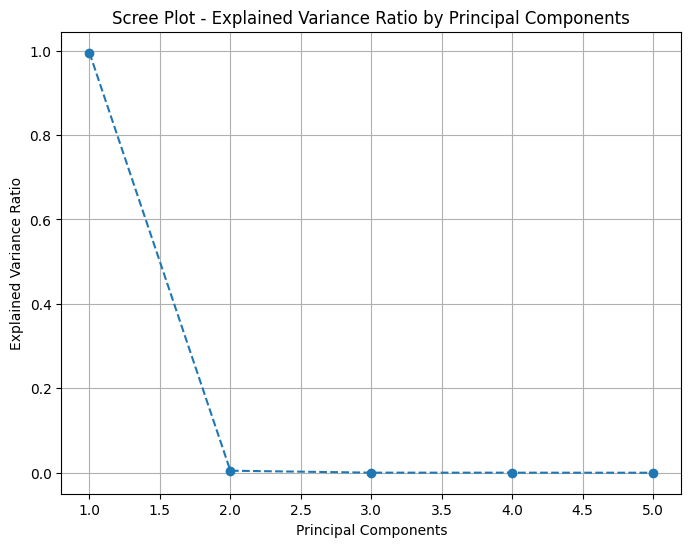

2024/12/18 05:26:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.6784, STD: 0.0062
🏃 View run likeable-gull-921 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/b800f98e652d445a9f8deb7f9da6239d
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14
🏃 View run Experiment 5 - PCA with 5 components at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/5431f607f5b64c59a6026d954b3d1985
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14


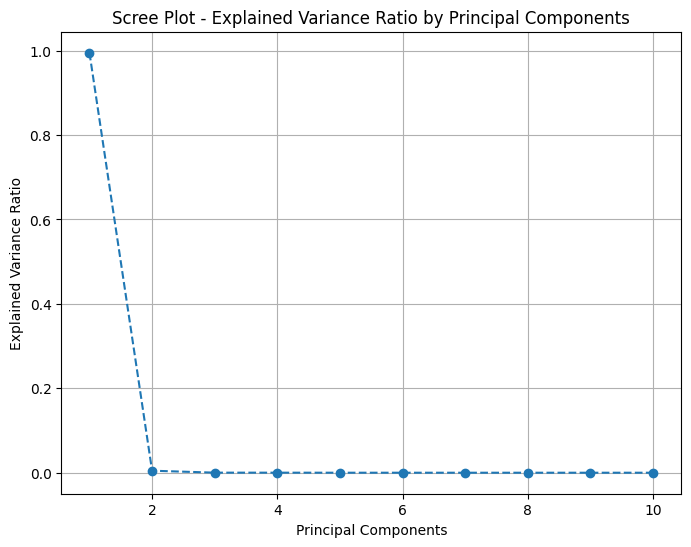

2024/12/18 05:27:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.7144, STD: 0.0054
🏃 View run welcoming-snail-139 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/738d9286cf4646d7adcf84c31dcbb234
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14
🏃 View run Experiment 5 - PCA with 10 components at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/3fad09d07f044f4e8cad4950555dc1cb
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14


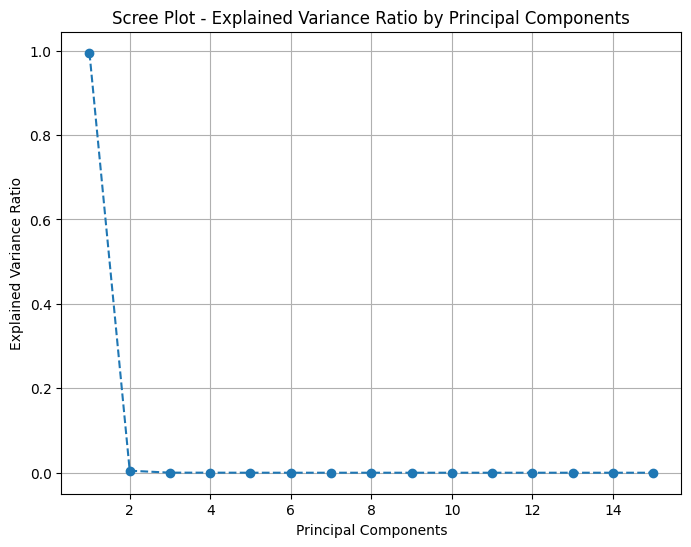

2024/12/18 05:28:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.7662, STD: 0.0076
🏃 View run bedecked-swan-462 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/79e3f899ca99441b8ee16cb70041c726
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14
🏃 View run Experiment 5 - PCA with 15 components at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/78403c0307d2454892c55d66ba6eefb0
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14


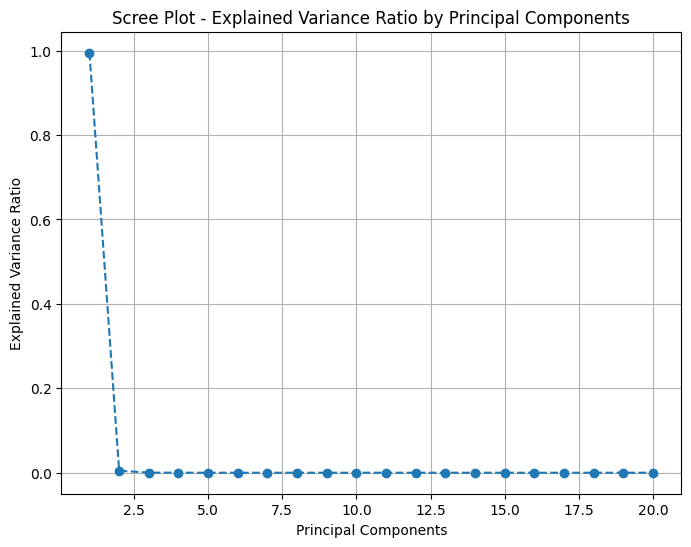

2024/12/18 05:30:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model: RandomForestClassifier
Mean CV F1-Score: 0.7709, STD: 0.0072
🏃 View run rumbling-gnu-632 at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/47953eecb11d42498c88f8573042e65a
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14
🏃 View run Experiment 5 - PCA with 20 components at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14/runs/ece5867250bb477cbed81c06155c935d
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/14


In [257]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# Apply PCA for dimensionality reduction
def pca_experiment(X_train, X_test, y_train, y_test, n_components=None):
    # Initialize PCA
    pca = PCA(n_components=n_components)

    # Fit PCA on training data
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Create a scree plot (explained variance ratio)
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
    plt.title("Scree Plot - Explained Variance Ratio by Principal Components")
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(True)
    plt.show()

    # Log PCA components and explained variance to MLFlow
    mlflow.log_param("PCA_n_components", n_components)
    mlflow.log_param("Explained_Variance_Ratio", pca.explained_variance_ratio_.tolist())

    # Now, we can apply classification models on the reduced features (X_train_pca and X_test_pca)
    models = {
        "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
    }

    for model_name, model in models.items():
        # Nested run to avoid parameter overwriting
        with mlflow.start_run(nested=True):
            mlflow.log_param("Model", model_name)

            # Define a pipeline for the model
            pipeline = Pipeline([
                ("classifier", model)
            ])

            # Cross-Validation
            kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            scores = cross_val_score(pipeline, X_train_pca, y_train, cv=kfold, scoring="f1_macro")
            mean_score = scores.mean()
            std_score = scores.std()

            # Train the model on the full training data
            pipeline.fit(X_train_pca, y_train)
            y_pred = pipeline.predict(X_test_pca)
            f1 = f1_score(y_test, y_pred)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

            # Log metrics to MLFlow
            mlflow.log_metric("Mean_CV_F1", mean_score)
            mlflow.log_metric("STD_CV_F1", std_score)
            mlflow.log_metric("F1-Score", f1)
            mlflow.log_metric("TP", tp)
            mlflow.log_metric("TN", tn)
            mlflow.log_metric("FP", fp)
            mlflow.log_metric("FN", fn)

            # Log the model to MLFlow
            mlflow.sklearn.log_model(pipeline, f"{model_name}_pipeline")

            print(f"Model: {model_name}")
            print(f"Mean CV F1-Score: {mean_score:.4f}, STD: {std_score:.4f}")

# Run the PCA experiment
for n_components in [5, 10, 15, 20]:  # Test with different numbers of components
    with mlflow.start_run(run_name=f"Experiment 5 - PCA with {n_components} components"):
        pca_experiment(X_train, X_test, y_train, y_test, n_components)


## 8.6 PCA Dimensionality Reduction
Apply PCA transformation and visualize explained variance with scree plots.

# Experiment 6: Handling Class Imbalance with SMOTE

**Objective**: Address class imbalance in the target variable  
**Technique**: Synthetic Minority Over-sampling Technique (SMOTE)  
**Benefit**: Generate synthetic samples for the minority class to balance the dataset  
**Model**: Random Forest with SMOTE preprocessing

In [258]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline

In [259]:
mlflow.set_experiment("Experiment #6")


2024/12/18 05:30:29 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #6' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/61e15b66b9054dce99ed31356187c997', creation_time=1734499829594, experiment_id='15', last_update_time=1734499829594, lifecycle_stage='active', name='Experiment #6', tags={}>

In [260]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Initialize SMOTE to oversample the minority class
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Create a pipeline that applies SMOTE and then fits a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
pipeline = imPipeline(steps=[('smote', smote), ('classifier', model)])

## 8.7 Apply SMOTE Oversampling
Create balanced training set using SMOTE and build pipeline with Random Forest.

In [261]:
with mlflow.start_run(run_name="SMOTE Analysis Experiment"):

    # Fit the model on the resampled training data
    pipeline.fit(X_train, y_train)

    # Predict on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    f1 = f1_score(y_test, y_pred, average='macro')
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    report = classification_report(y_test, y_pred, output_dict=True)

    # Log the metrics and confusion matrix to MLFlow
    mlflow.log_metric("F1_Score", f1)
    mlflow.log_metric("TP", tp)
    mlflow.log_metric("TN", tn)
    mlflow.log_metric("FP", fp)
    mlflow.log_metric("FN", fn)

    # Log the classification report as a JSON string
    mlflow.log_param("Classification_Report", str(report))

    # Log the trained model
    mlflow.sklearn.log_model(pipeline, "smote_random_forest_model")

    # Output evaluation results
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
    print(f"Classification Report: \n{classification_report(y_test, y_pred)}")

2024/12/18 05:31:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


F1-Score: 0.7808
Confusion Matrix: 
[[3582  370]
 [ 447  807]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      3952
           1       0.69      0.64      0.66      1254

    accuracy                           0.84      5206
   macro avg       0.79      0.77      0.78      5206
weighted avg       0.84      0.84      0.84      5206

🏃 View run SMOTE Analysis Experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/15/runs/599ce6a412964245a1d7cc7374d096f0
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/15


# Experiment 7: t-SNE Visualization

**Objective**: Visualize high-dimensional data in 2D space  
**Technique**: t-Distributed Stochastic Neighbor Embedding (t-SNE)  
**Purpose**: 
- Understand data structure and clustering patterns
- Identify class separability
- Detect potential outliers

**Preprocessing**: StandardScaler applied before t-SNE transformation

In [263]:
mlflow.set_experiment("Experiment #7")

2024/12/18 05:31:25 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #7' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/eeb9781dc995498cbeeab1edc38b25d1', creation_time=1734499885101, experiment_id='16', last_update_time=1734499885101, lifecycle_stage='active', name='Experiment #7', tags={}>

Explained Variance by PCA (top 5 components): [0.0421921  0.02894345 0.02618861 0.02226558 0.01839992]
t-SNE visualization saved at: tsne_plot.png
🏃 View run t-SNE Dimensionality Reduction Experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/16/runs/7a68d4c7a6a441d7a2f9c578b1e4a6ab
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/16


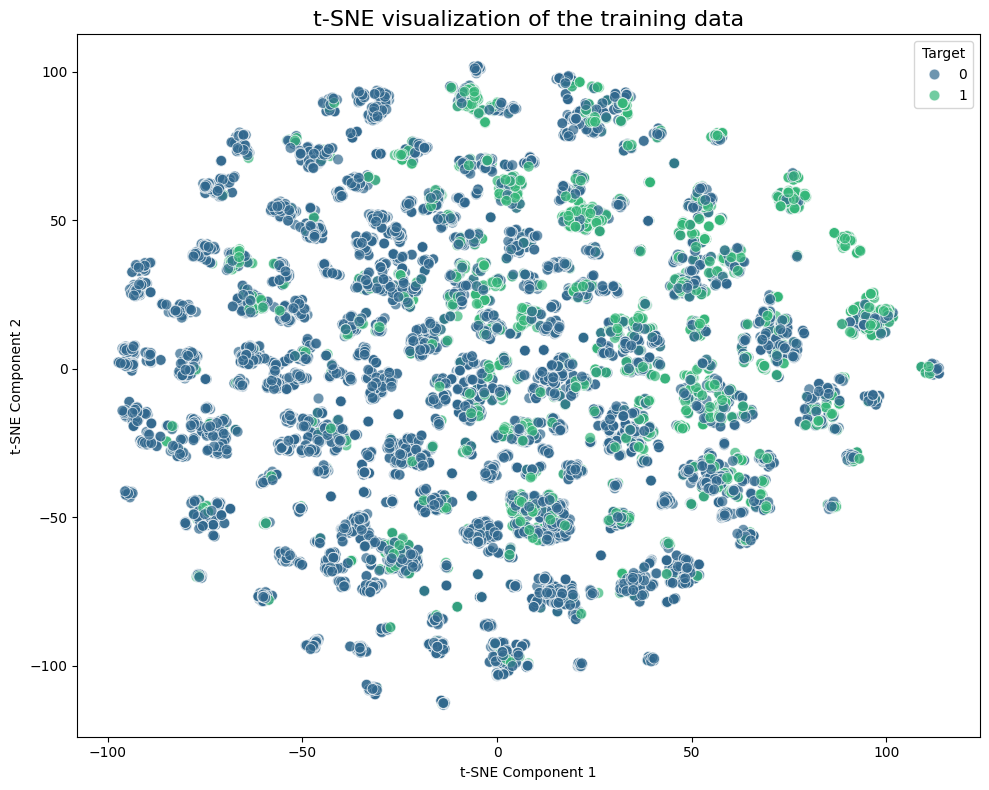

In [265]:
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Assuming X_train and y_train are your features and labels
# X_train = <Your Feature Data>
# y_train = <Your Target Labels>

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Standardizing the features (important for t-SNE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize and fit t-SNE with the scaled features
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)

# Visualize the t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train, palette="viridis", s=60, alpha=0.7)
plt.title("t-SNE visualization of the training data", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Target", loc="best")
plt.tight_layout()

# Log the t-SNE visualization in MLFlow
with mlflow.start_run(run_name="t-SNE Dimensionality Reduction Experiment"):
    # Log the t-SNE plot as an artifact in MLFlow
    plot_path = "tsne_plot.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)

    # Log the explained variance (before applying t-SNE, PCA could be used for dimensionality reduction if needed)
    pca = PCA(n_components=5)
    X_pca = pca.fit_transform(X_train_scaled)
    explained_variance = pca.explained_variance_ratio_

    # Log PCA explained variance ratio
    mlflow.log_metric("PCA_Explained_Variance_Ratio", explained_variance.sum())

    # Optionally log the PCA components and t-SNE components for reference
    mlflow.log_param("PCA_Components", str(pca.components_))
    mlflow.log_param("t-SNE_Components", str(X_tsne[:5]))  # Log the first 5 rows of t-SNE components

    # Output evaluation results
    print(f"Explained Variance by PCA (top 5 components): {explained_variance}")
    print(f"t-SNE visualization saved at: {plot_path}")


## 8.8 Apply t-SNE Dimensionality Reduction
Transform features to 2D space and create scatter plot visualization colored by income class.

In [273]:
mlflow.set_experiment("Experiment #8")

2024/12/18 06:16:23 INFO mlflow.tracking.fluent: Experiment with name 'Experiment #8' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/8a15fd545f3c426abadc4fcbc0bfbde3', creation_time=1734502583244, experiment_id='17', last_update_time=1734502583244, lifecycle_stage='active', name='Experiment #8', tags={}>

# Experiment 8: Model Performance Comparison

**Objective**: Visual comparison of F1-scores across different models  
**Models**: Logistic Regression, Random Forest, Ridge Classifier  
**Visualization**: Bar plot comparing F1-scores  
**Purpose**: Identify the best performing model for final deployment

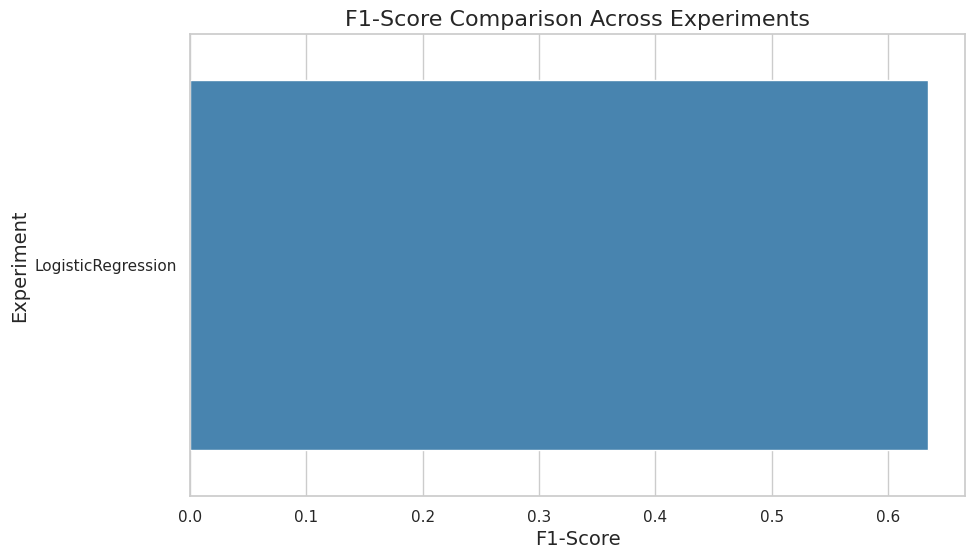

🏃 View run LogisticRegression at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17/runs/1bf7629d67ef49fda451b2dfb1cc3200
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17


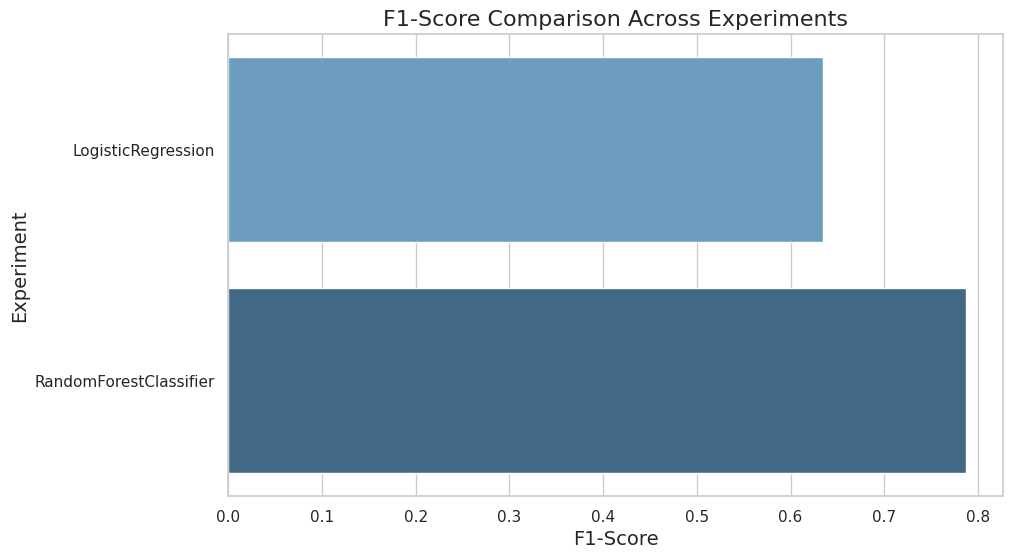

🏃 View run RandomForestClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17/runs/35f4bfcc57e64b479e24b079c635c919
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17


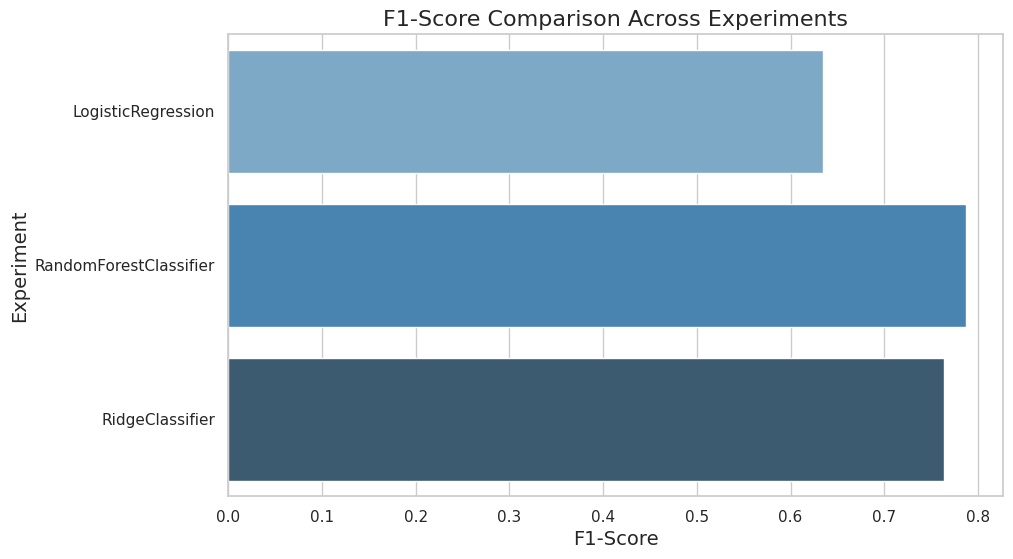

🏃 View run RidgeClassifier at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17/runs/3e533cb7c561427c9e23cae91810872c
🧪 View experiment at: https://dagshub.com/Profit188/Clasification_Income.mlflow/#/experiments/17


In [274]:
import os
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define a function to run the models and log the results
def run_model(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test data
    y_pred = model.predict(X_test)

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred, average='macro')

    # Return the F1 score for logging and plotting
    return f1

# List of models (instantiating the models here)
models = [
    ('LogisticRegression', LogisticRegression()),  # Instantiate the model
    ('RandomForestClassifier', RandomForestClassifier()),  # Instantiate the model
    ('RidgeClassifier', RidgeClassifier())   # Instantiate the model
]

experiment_results = []

# Start an MLFlow run for each experiment
for experiment_name, model in models:
    with mlflow.start_run(run_name=experiment_name):
        # Run the model and get the F1 score
        f1 = run_model(model, X_train, y_train, X_test, y_test)

        # Log the F1 score to MLFlow
        mlflow.log_metric("F1_Score", f1)

        # Store the result for plotting
        experiment_results.append({'Experiment': experiment_name, 'F1_Score': f1})

        # Create a DataFrame with the results for plotting after the run
        df_1 = pd.DataFrame(experiment_results)

        # Set the style of the plot using seaborn
        sns.set(style="whitegrid")

        # Create a bar plot for F1-scores
        plt.figure(figsize=(10, 6))
        sns.barplot(x='F1_Score', y='Experiment', data=df_1, palette='Blues_d')

        # Add labels and title
        plt.title('F1-Score Comparison Across Experiments', fontsize=16)
        plt.xlabel('F1-Score', fontsize=14)
        plt.ylabel('Experiment', fontsize=14)

        # Save the plot to a file
        plot_filename = 'f1_score_comparison.png'
        plt.savefig(plot_filename)

        # Log the plot as an artifact in MLFlow
        mlflow.log_artifact(plot_filename)

        # Display the plot
        plt.show()

        # Remove the plot file after logging to avoid clutter
        os.remove(plot_filename)

## 8.9 Compare Model Performance
Train multiple models and create comparative visualization of F1-scores.

In [275]:
df_encoded.columns

Index(['Age', 'Hours_per_Week', 'Income', 'Education_Num', 'Capital_Gain',
       'Capital_Loss', 'Fnlwgt', 'Sex_Male', 'Relationship_Not-in-family',
       'Relationship_Other-relative', 'Relationship_Own-child',
       'Relationship_Unmarried', 'Relationship_Wife', 'Workclass_Federal-gov',
       'Workclass_Local-gov', 'Workclass_Never-worked', 'Workclass_Private',
       'Workclass_Self-emp-inc', 'Workclass_Self-emp-not-inc',
       'Workclass_State-gov', 'Workclass_Without-pay',
       'Occupation_Adm-clerical', 'Occupation_Armed-Forces',
       'Occupation_Craft-repair', 'Occupation_Exec-managerial',
       'Occupation_Farming-fishing', 'Occupation_Handlers-cleaners',
       'Occupation_Machine-op-inspct', 'Occupation_Other-service',
       'Occupation_Priv-house-serv', 'Occupation_Prof-specialty',
       'Occupation_Protective-serv', 'Occupation_Sales',
       'Occupation_Tech-support', 'Occupation_Transport-moving',
       'Native_Country_Cambodia', 'Native_Country_Canada',
    

In [276]:
X = df_encoded[['Age', 'Hours_per_Week', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Fnlwgt',
                'Sex_Male', 'Relationship_Not-in-family', 'Relationship_Own-child', 'Relationship_Unmarried',
                'Relationship_Wife', 'Workclass_Private', 'Occupation_Exec-managerial', 'Occupation_Prof-specialty',
                'Education_9', 'Age_to_hours_ratio', 'Age_squared', 'Hours_per_week_squared', 'Age_hours_interaction']]
y = df_encoded['Income']


# 9. Final Model Training and Deployment

## 9.1 Feature Selection for Production Model
Select the most important features based on insights from previous experiments.

In [277]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 9.2 Prepare Final Train-Test Split
Split data with selected features for final model training.

In [279]:
import joblib
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the trained model using joblib
joblib.dump(rf_model, 'random_forest_model.joblib')

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4940
           1       0.71      0.61      0.65      1568

    accuracy                           0.84      6508
   macro avg       0.79      0.76      0.78      6508
weighted avg       0.84      0.84      0.84      6508

Confusion Matrix:
[[4546  394]
 [ 617  951]]


['random_forest_model.joblib']

## 9.3 Train and Save Final Model
Train Random Forest classifier and save the model for deployment using joblib.

**Model Performance Metrics**:
- Classification Report (Precision, Recall, F1-Score)
- Confusion Matrix
- Model saved as: `random_forest_model.joblib`

In [ ]:
# 10. Conclusion and Next Steps

## Project Summary

This notebook demonstrated a comprehensive machine learning pipeline for income classification:

1. **Data Preprocessing**: Raw Python cleaning and SQL normalization (3NF)
2. **EDA**: Statistical analysis and visualization
3. **Feature Engineering**: Created polynomial and interaction features
4. **Model Selection**: Compared Logistic Regression, Ridge, Random Forest, and XGBoost
5. **Optimization**: Applied feature selection, PCA, SMOTE, and hyperparameter tuning
6. **Experiment Tracking**: Logged all experiments using MLflow

## Key Findings

- **Best Model**: Random Forest Classifier showed the best performance
- **Important Features**: Age, Hours per Week, Education, and engineered features
- **Class Imbalance**: SMOTE improved minority class prediction
- **Feature Engineering**: Polynomial features captured non-linear relationships

## Next Steps

1. Deploy model using FastAPI/Streamlit (see `/app` folder)
2. Implement real-time prediction API
3. Monitor model performance in production
4. Retrain model with new data periodically
5. A/B testing for model improvements

## Model Deployment

The trained model is saved as `random_forest_model.joblib` and can be loaded for predictions:

```python
import joblib
model = joblib.load('random_forest_model.joblib')
predictions = model.predict(new_data)
```